# Property Scanner: Multimodal AI Valuation System

## 1. Project Overview
**Objective**: Predict property prices in Spanish cities (Madrid, Barcelona, etc.) using a **Multimodal Late-Fusion Model**.

**Key Innovation**: Unlike traditional comparable approaches that only use numbers (sqm, rooms), this system "sees" the property using a **Vision Language Model (VLM)** to extract qualitative features (condition, style, finishes) from images and fuses them with quantitative data.


## 2. System Architecture

The system uses a state-of-the-art **Agentic Pipeline** to transform raw web data into reasoned valuations.

### Pipeline Stages:
1.  **Extraction Agent**: Scrapes and normalizes raw data into `CanonicalListing` objects.
2.  **Vision Agent (VLM)**: Deep-inspects photos using **Llava/Ollama** to describe interiors and finishes.
3.  **Embedding Engine**: Converts text and descriptions into **384D vectors** via SentenceTransformers.
4.  **Fusion Model**: A custom PyTorch model that performs **Cross-Attention** between the target property and local market comparables.


## 3. Data Inspection

Let's look at the data collected in `data/listings.db`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json
import seaborn as sns
import sys
import os

# Ensure we can import from src
sys.path.append('..')

# Connect to Database
conn = sqlite3.connect('../data/listings.db')
df = pd.read_sql_query("SELECT * FROM listings WHERE price > 0", conn)
conn.close()

print(f"Total Listings: {len(df)}")
display(df[['id', 'title', 'price', 'city', 'vlm_description']].head())

Total Listings: 2442


,id,title,price,city,vlm_description
0,d01dfab5724aafce35f0e15411d42171,Casa adosada en Pasaje Fuente Del Cura,255000.0,Unknown,None
1,f5eda6e9644ffb6057269c04b33d5627,"Chalet en Avenida de La Cabrera, 27",459000.0,Unknown,None
2,fb8b62a11196330e3baa10b614d0c52b,Chalet en calle Centro,409000.0,Unknown,None
3,9ed098ec6c11752ef44c44427db67c15,Chalet en Carretera de Valdemanco,409000.0,Unknown,None
4,eb20d968e7e3083f043a0b4a8af93aa4,Piso en calle de Almansa,850000.0,Unknown,None


### 3.1 Market Composition: City Breakdown
Where is our data coming from? We've expanded to include the most active real estate markets in Spain.

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_50712/3550406612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')


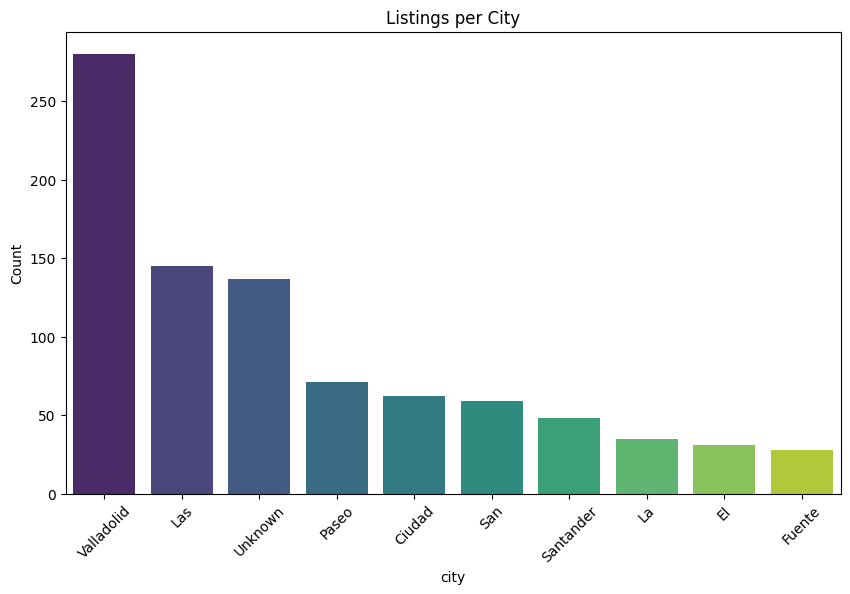

In [2]:
plt.figure(figsize=(10, 6))
city_counts = df['city'].value_counts()[:10]
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')
plt.title('Listings per City')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

### 3.2 Geospatial Analysis
Visualizing the spatial density of our properties.

In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Filter out valid coordinates
geo_df = df[(df['lat'] != 0) & (df['lon'] != 0)]

# Major Cities for Reference
cities_data = {
    'City': ['Madrid', 'Barcelona', 'Valencia', 'Seville', 'Zaragoza', 'Málaga'],
    'Lat': [40.4168, 41.3851, 39.4699, 37.3891, 41.6488, 36.7212],
    'Lon': [-3.7038, 2.1734, -0.3763, -5.9845, -0.8891, -4.4214]
}
cities_df = pd.DataFrame(cities_data)

# Create Plotly Map with Satellite Background (Esri)
fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
                        color_continuous_scale='Viridis', size_max=15, zoom=5, height=600,
                        hover_data=['price', 'city'], title='Property Distribution (Satellite View)')

# Add City Labels
fig.add_trace(go.Scattermapbox(
    lat=cities_df['Lat'],
    lon=cities_df['Lon'],
    mode='markers+text',
    marker=go.scattermapbox.Marker(size=12, color='red'),
    text=cities_df['City'],
    textposition='top right',
    name='Major Cities'
))

# Update layout to use Esri World Imagery (Satellite) tiles
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "Esri, Maxar, Earthstar Geographics",
            "source": [
                "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ]
        }
    ],
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.show()

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_50712/737516324.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_50712/737516324.py:21: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### 3.3 Data Quality Analysis

Understanding data completeness is crucial. The chart below visualizes the percentage of missing values for each feature in our dataset.

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_50712/1432240471.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




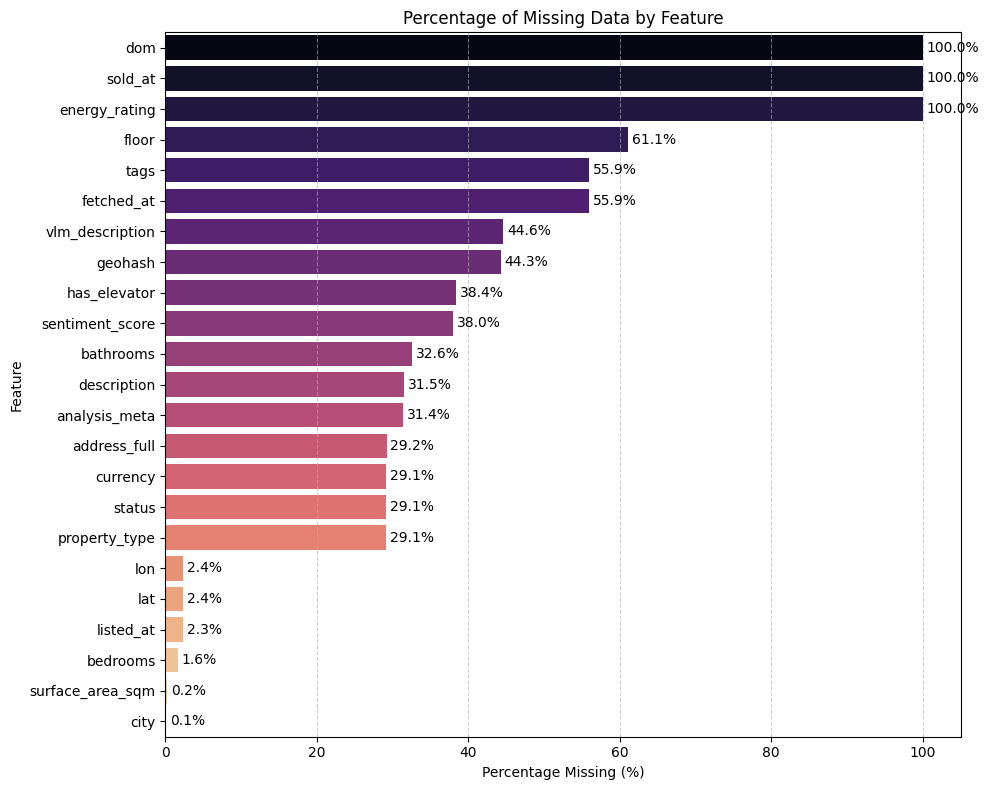

In [4]:
# Connect to Database to get full dataset
conn = sqlite3.connect('../data/listings.db')
quality_df = pd.read_sql_query("SELECT * FROM listings", conn)
conn.close()

# Calculate missing percentages
missing_props = quality_df.isnull().sum() / len(quality_df) * 100
# Filter properties that actually have missing data
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

if not missing_props.empty:
    # Visualize
    plt.figure(figsize=(10, 8))
    sns.barplot(x=missing_props.values, y=missing_props.index, palette='magma')
    plt.title('Percentage of Missing Data by Feature')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Add value labels
    for i, v in enumerate(missing_props.values):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Amazing! No missing data found in the dataset.")

## 4. VLM: The Visual Intelligence

Traditional models miss detail. Our VLM captures descriptions like *"modern open-concept kitchen"* or *"ranch-style villa with pool"*.

In [5]:
vlm_enriched = df[df['vlm_description'].notna() & (df['vlm_description'] != '')]
print(f"Enriched Listings: {len(vlm_enriched)}")

if not vlm_enriched.empty:
    sample = vlm_enriched.sample(1).iloc[0]
    print(f"\nProperty: {sample['title']}")
    print("VLM Insight:", sample['vlm_description'][:400] + "...")

Enriched Listings: 1356

Property: Casa adosada en calle Ntra Sra Dolores
VLM Insight:  The image shows an interior hallway with a modern design. Here's the analysis:
1. Room Type: Hallway or corridor.
2. Condition: Renovated or newly decorated.
3. Quality: Modern and well-maintained.
4. Key Value-Affecting Features:
   - Natural Light: The hallway is well lit, suggesting large windows not visible in the photo. This could enhance the perceived space and value.
   - Views: There are ...


## 5. Model Training & Performance

Below is the current training convergence for the **92k-parameter compact model**.

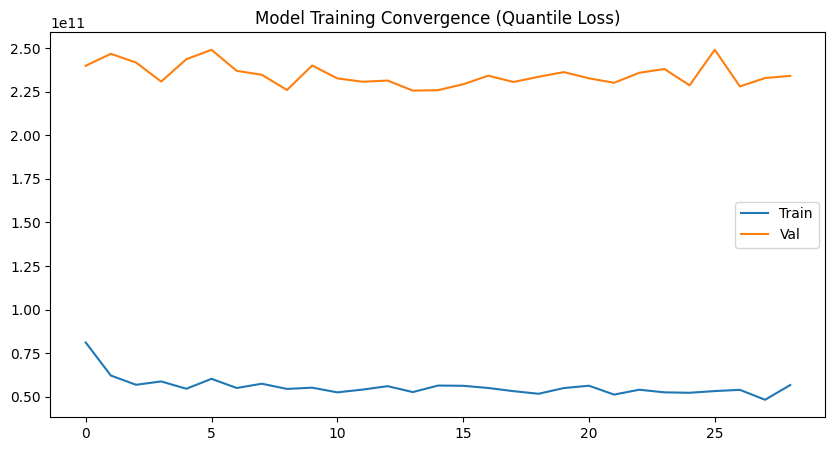

In [6]:
import torch
import matplotlib.pyplot as plt
checkpoint_path = '../models/checkpoint_latest.pt'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    plt.figure(figsize=(10, 5))
    plt.plot(ckpt['train_losses'], label='Train')
    plt.plot(ckpt['val_losses'], label='Val')
    plt.title('Model Training Convergence (Quantile Loss)')
    plt.legend()
    plt.show()
else:
    print("Checkpoint not found. Run training first.")

## 6. Live Inference Example

Compare the AI's valuation with the actual market price.

In [7]:
from src.training.dataset import PropertyDataset, collate_fn
from src.services.fusion_model import PropertyFusionModel
import torch
import numpy as np

# Set up dataset and sample
ds = PropertyDataset(db_path='../data/listings.db', use_vlm=True)
idx = np.random.randint(0, len(ds))
item = ds[idx]
batch = collate_fn([item])

# Load Model
model = PropertyFusionModel(hidden_dim=64, num_heads=2) # Compact settings
if os.path.exists('../models/fusion_model.pt'):
    model.load_state_dict(torch.load('../models/fusion_model.pt', map_location='cpu'))
    model.eval()
    with torch.no_grad():
        q, _, _, _ = model(
            target_tab=batch['target_tab'], 
            target_text=batch['target_text'],
            comp_tab=batch['comp_tab'], 
            comp_text=batch['comp_text'], 
            comp_prices=batch['comp_prices'],
            target_image=None,
            comp_image=None
        )
        
    actual = batch['target_price'][0].item()
    pred = q[0, 1].item()
    print(f"Title: {ds.listings[idx]['title']}")
    print(f"Actual: €{actual:,.0f} | Predicted: €{pred:,.0f} | Error: {abs(actual-pred)/actual*100:.1f}%")
else:
    print("Model weights not found. Prediction skipped.")

2026-01-13 13:04:13 [info     ] text_encoder_initialized       dim=384 model=all-MiniLM-L6-v2


2026-01-13 13:04:13 [info     ] dataset_initialized            db_path=../data/listings.db num_cities=574 num_listings=2442 vlm_enabled=True


2026-01-13 13:04:13 [info     ] tabular_encoder_fitted         features=10


2026-01-13 13:04:13 [info     ] tabular_encoder_fitted         num_samples=2442


Title: Casa rústica en venta en Calle Eucaliptos
Actual: €150,000 | Predicted: €811,078,778,880 | Error: 540719085.9%


### 3.4 Data Cleaning: Outlier Removal

To ensure data quality, we remove records with values that are physically impossible or highly improbable (e.g., extreme prices, invalid floors).

In [8]:
# Simple Cleaner Logic
original_count = len(df)

# Define sensible bounds for our features
guards = {
    'price': {'min': 10000, 'max': 10000000},
    'floor': {'min': -5, 'max': 70},
    'surface_area_sqm': {'min': 10, 'max': 5000},
    'bedrooms': {'min': 0, 'max': 25},
    'bathrooms': {'min': 0, 'max': 20}
}

print(f"Starting Data Cleaning (Rows: {original_count})...")

for col, bounds in guards.items():
    if col in df.columns:
        # Filter outliers
        mask = (df[col] < bounds['min']) | (df[col] > bounds['max'])
        n_dropped = mask.sum()
        if n_dropped > 0:
            print(f" - Removing {n_dropped} outliers in '{col}' (Allowed: {bounds['min']} - {bounds['max']})")
            df = df[~mask]

print(f"Cleaning Complete. Final Rows: {len(df)} (Total Removed: {original_count - len(df)})")

Starting Data Cleaning (Rows: 2442)...
 - Removing 88 outliers in 'price' (Allowed: 10000 - 10000000)
 - Removing 21 outliers in 'floor' (Allowed: -5 - 70)
 - Removing 106 outliers in 'surface_area_sqm' (Allowed: 10 - 5000)
Cleaning Complete. Final Rows: 2227 (Total Removed: 215)


### 3.5 Feature Distributions

Let's create violin plots for all numerical features to understand their distributions.

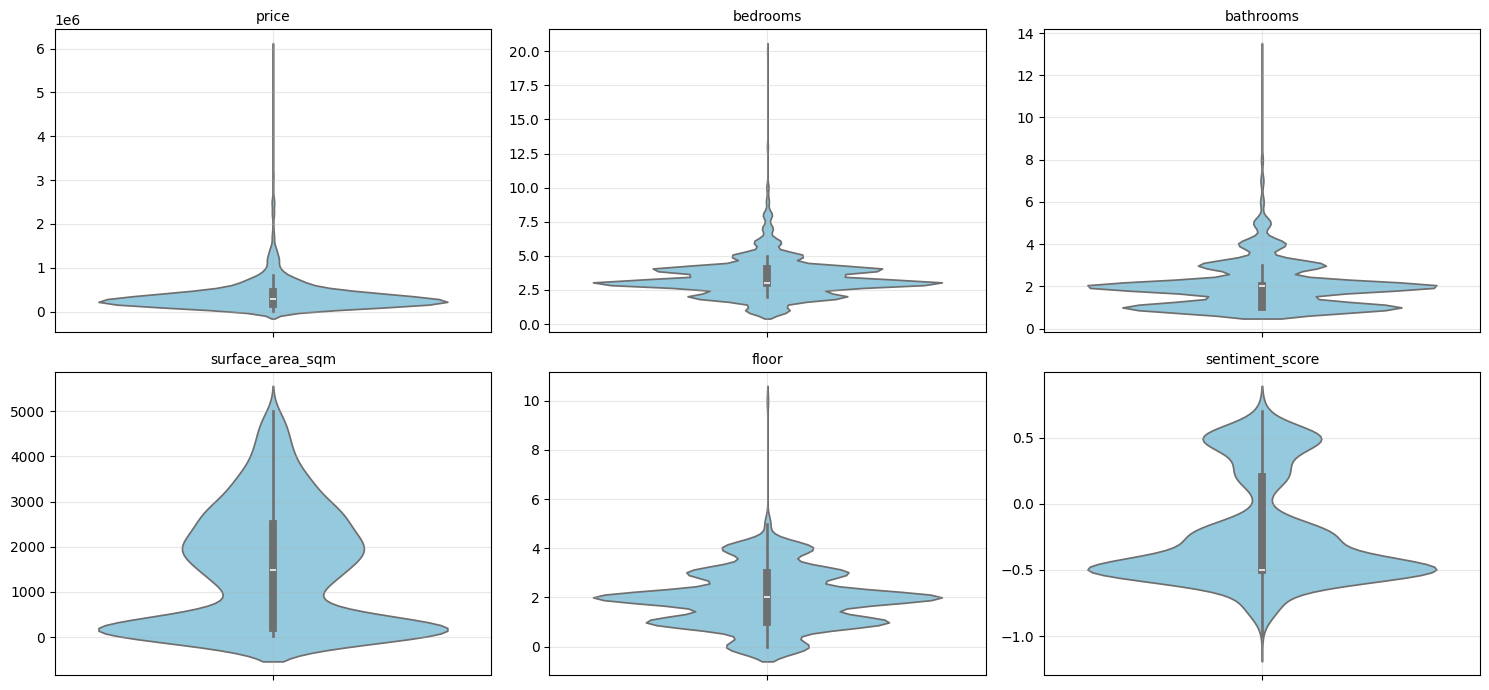

In [9]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Exclude boolean-like or specific columns that don't make sense for violin plots
exclude_cols = ['has_elevator', 'lat', 'lon'] 
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Set up a more compact plotting layout
n_cols = 3  # Increased columns for compactness
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Reduced height multiplier to make it more compact vertically
plt.figure(figsize=(15, 3.5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=10)
    plt.ylabel('') # Remove y-label to save space, usually title is enough
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 VLM Description Coverage
Analysis of how many listings have Vision Language Model descriptions generated from images.


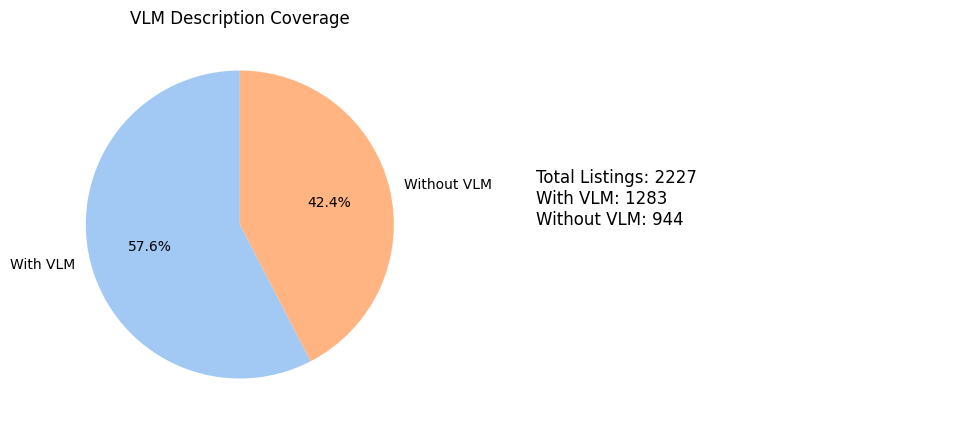


--- 4 Random VLM Description Examples ---

Example 1:
 The property in the image appears to be a multi-family residential building with an exterior that suggests it is well-maintained and potentially recently renovated or constructed. Here's an analysis:

1) Room type:
   - Exterior: The photo includes both front and side views of the building, which s...

Example 2:
 The image displays a residential area with multiple-story apartment buildings. In the foreground, there is a well-maintained and recently renovated building. We can observe that there are two levels of apartments, each with balconies equipped with outdoor furniture. Exteriors show clean lines and m...

Example 3:
 The image depicts a residential property with the following characteristics:

1. Room type: It appears to be an exterior view of a single-story house that includes a living room, dining area, kitchen, two bedrooms, and a bathroom.

2. Condition: The property seems to be in good condition, showing n...

Example 

In [10]:
# VLM Statistics
vlm_mask = df['vlm_description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
vlm_counts = vlm_mask.value_counts()
vlm_counts.index = ['With VLM', 'Without VLM'] if vlm_counts.index[0] == True else ['Without VLM', 'With VLM']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[0:2]
plt.pie(vlm_counts, labels=vlm_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('VLM Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith VLM: {vlm_mask.sum()}\nWithout VLM: {len(df) - vlm_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random VLM Description Examples ---')
if vlm_mask.sum() > 0:
    for i, desc in enumerate(df[vlm_mask]['vlm_description'].sample(min(4, vlm_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')


### 3.4 Text Description Coverage
Analysis of standard text descriptions provided in the listings.


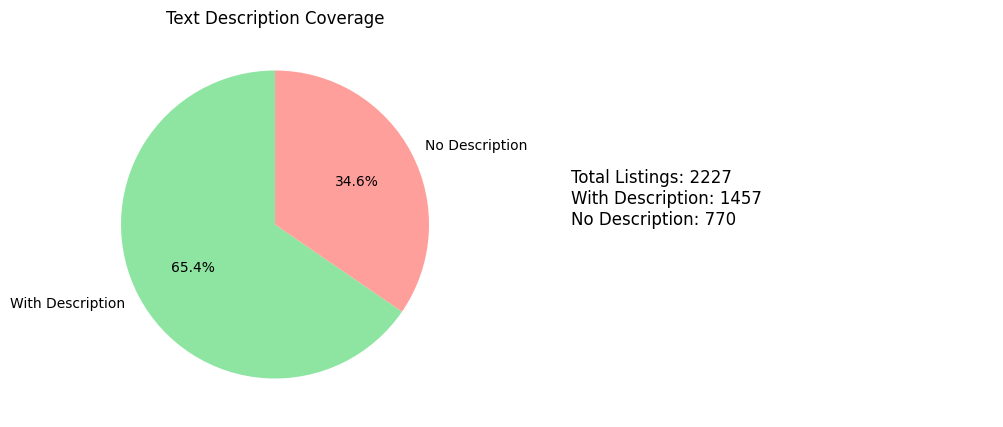


--- 4 Random Text Description Examples ---

Example 1:
Ésta magnífica propiedad  situada en la zona de Camins al Grau a 100 metros de la AV DEL PUERTO, cuenta con una superficie de 50 metros cuadrados. Su distribución destaca por dos estancias de un dormitorio de matrimonio, un cuarto de baño amplio y moderno, una cocina abierta conectada con un salón l...

Example 2:
Superficie total 15406 m², hab. individuales: 4, 3 baños, estado conservación: reformado, nº de planta: 1....

Example 3:
Descubre esta estupenda vivienda situada en una de las zonas más valoradas de Alicante, un entorno que combina naturaleza, servicios y una calidad de vida difícil de igualar. Ubicado frente al campo de golf y a pocos minutos de la playa, este piso es perfecto para quienes buscan espacio, tranquilida...

Example 4:
Viviendas de 1 dormitorio 59 m2 construidos con comunes, 39,20 m²útiles y 8,20m2 de terraza, desde 161.000 € + IVA. (plano 1D.02)...


In [11]:
# LLM/Text Statistics
text_mask = df['description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
text_counts = text_mask.value_counts()
text_counts.index = ['With Description', 'No Description'] if text_counts.index[0] == True else ['No Description', 'With Description']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[2:4]
plt.pie(text_counts, labels=text_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Text Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith Description: {text_mask.sum()}\nNo Description: {len(df) - text_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random Text Description Examples ---')
if text_mask.sum() > 0:
    for i, desc in enumerate(df[text_mask]['description'].sample(min(4, text_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')
